#### imports

In [1]:
%run CleanData.ipynb

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
                                     MaxPool1D, Bidirectional, GRU,
                                     Dropout, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ----------------------------------------------------
# 0.  Imports (only if not already imported)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# ==================== OPTIONAL: extra scaling ====================
# comment out if CleanData already normalised signals
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [3]:
# ==================== reshape & one-hot ==========================
X_train = X_train.reshape((-1, X_train.shape[1], 1))
X_test  = X_test.reshape((-1,  X_test.shape[1], 1))


num_classes = 6
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

# ===== validation split =====
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train, y_train_cat,
    test_size=0.15, stratify=y_train,
    random_state=42
)

In [4]:
# ==================== focal-loss CLASS ===========================
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=1.0,
                 from_logits=False,
                 reduction='sum_over_batch_size',
                 name='focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma       = gamma
        self.alpha       = tf.constant(alpha, dtype=tf.float32)
        self.from_logits = from_logits

    def call(self, y_true, y_pred):        # <-- fixed name
        y_true = tf.cast(y_true, y_pred.dtype)
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        alpha_t = (tf.reduce_sum(y_true * self.alpha, axis=-1)
                   if self.alpha.shape.rank == 1 else self.alpha)
        focal = tf.pow(1.0 - p_t, self.gamma)
        loss  = -alpha_t * focal * tf.math.log(tf.clip_by_value(p_t, 1e-7, 1.0))
        return loss


In [5]:
# ===== focal-loss instance =====
alpha_vec = [class_weights[i] for i in range(len(class_weights))]
loss_fn   = FocalLoss(gamma=2.0, alpha=alpha_vec, from_logits=True)


In [6]:
# ==================== model ==========================
SEQ_LEN, N_CHANNELS = X_train.shape[1:]
inputs = Input(shape=(SEQ_LEN, N_CHANNELS))

x = Conv1D(64, 5, padding='same', activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPool1D(2)(x)

x = Conv1D(128, 5, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPool1D(2)(x)

x = Bidirectional(GRU(64))(x)
x = Dropout(0.3)(x)

logits = Dense(num_classes)(x)  # raw logits
model  = tf.keras.Model(inputs, logits)
model.summary()

# ==================== compile ========================
model.compile(
    optimizer = Adam(1e-3),
    loss      = loss_fn,
    metrics   = ['accuracy',
                 tf.keras.metrics.Precision(name='prec'),
                 tf.keras.metrics.Recall(name='rec'),
                 tf.keras.metrics.AUC(curve='PR', name='pr_auc')]
)

# ==================== train ==========================
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc',
                                         factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc',
                                     mode='max', patience=8,
                                     restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    validation_data = (X_val, y_val_cat),
    epochs          = 20,
    batch_size      = 256,
    callbacks       = callbacks,
    verbose         = 2
)

def get_current_lr(opt):
    lr_attr = getattr(opt, "lr", None) or opt.learning_rate
    # if it's a schedule, you can still read its current value
    if callable(lr_attr):          # schedule object
        return tf.keras.backend.get_value(lr_attr(opt.iterations))
    else:                          # float or tf.Variable
        return float(lr_attr)

def set_new_lr(opt, value):
    lr_attr = getattr(opt, "lr", None) or opt.learning_rate

    # Case 1: tf.Variable  ➜ assign
    if isinstance(lr_attr, tf.Variable):
        lr_attr.assign(value)

    # Case 2: plain float  ➜ just overwrite the attribute
    elif isinstance(lr_attr, (float, int)):
        if hasattr(opt, "lr"):        # TF ≤ 2.10
            opt.lr = value
        else:                         # TF 2.11+
            opt.learning_rate = value

    # Case 3: schedule object  ➜ replace with constant value or new schedule
    else:
        opt.learning_rate = value     # convert schedule → constant


# ==================== resume training ==========================
# --- 1. Get current LR and cut it again --------------------------
old_lr = get_current_lr(model.optimizer)
new_lr = max (old_lr * 0.3, 1e-6)          # lower the LR
set_new_lr(model.optimizer, new_lr)  # set the new LR
print(f"Resuming training with LR={new_lr:.2e}")

# --- 2. Fresh callbacks ------------------------------------------
callbacks2 = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_pr_auc',
        factor=0.5,
        patience=3,
        min_lr=1e-6,  
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_pr_auc',
        mode='max',
        patience=5,            # shorter leash this time
        restore_best_weights=True,
        verbose=1
    )
]

# --- 3. Resume fit -----------------------------------------------
history2 = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    initial_epoch=len(history.history['loss']),  # continues epoch count
    epochs        = 60,                          # or any high ceiling
    batch_size    = 256,
    callbacks     = callbacks2,
    verbose       = 2
)

# ==================== evaluate ========================
test_metrics = model.evaluate(X_test, y_test_cat, batch_size=256, verbose=0)
print(dict(zip(model.metrics_names, test_metrics)))

# ==================== decode demo =====================
def decode_predictions(probs, cond_dict):
    return [cond_dict[int(i)] for i in np.argmax(probs, axis=-1)]

sample_probs = tf.nn.softmax(model.predict(X_test[:10]), axis=-1).numpy()
print(decode_predictions(sample_probs, conditions))

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 133, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 133, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 133, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 66, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 66, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 66, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,510 (459.02 KB)

 Trainable params: 117,126 (457.52 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20
330/330 - 31s - 94ms/step - accuracy: 0.8680 - loss: 0.2815 - pr_auc: 0.5497 - prec: 0.4445 - rec: 0.9694 - val_accuracy: 0.8147 - val_loss: 0.4921 - val_pr_auc: 0.6520 - val_prec: 0.5011 - val_rec: 0.9752 - learning_rate: 1.0000e-03
Epoch 2/20
330/330 - 53s - 161ms/step - accuracy: 0.9175 - loss: 0.1522 - pr_auc: 0.5196 - prec: 0.4325 - rec: 0.9930 - val_accuracy: 0.9399 - val_loss: 0.1186 - val_pr_auc: 0.5091 - val_prec: 0.4264 - val_rec: 0.9946 - learning_rate: 1.0000e-03
Epoch 3/20
330/330 - 26s - 78ms/step - accuracy: 0.9379 - loss: 0.1140 - pr_auc: 0.5262 - prec: 0.4413 - rec: 0.9948 - val_accuracy: 0.9425 - val_loss: 0.1109 - val_pr_auc: 0.5094 - val_prec: 0.4306 - val_rec: 0.9952 - learning_rate: 1.0000e-03
Epoch 4/20
330/330 - 38s - 114ms/step - accuracy: 0.9499 - loss: 0.0933 - pr_auc: 0.5337 - prec: 0.4484 - rec: 0.9964 - val_accuracy: 0.9397 - val_loss: 0.0975 - val_pr_auc: 0.5243 - val_prec: 0.4547 - val_rec: 0.9957 - learning_rate: 1.0000e-03
Epoch 5/20

Epoch 

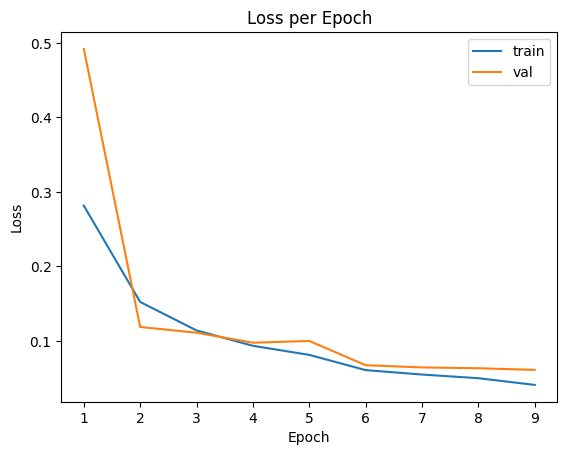

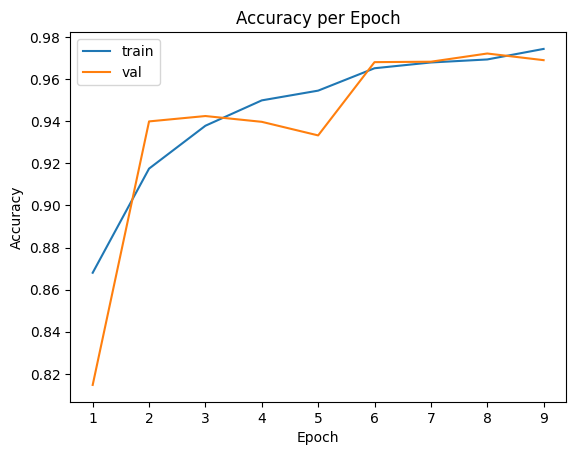

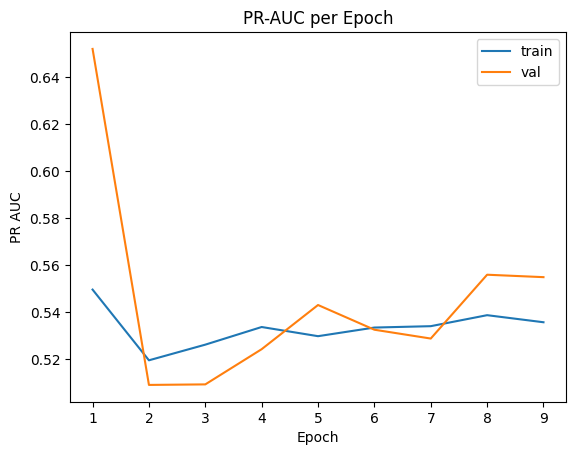

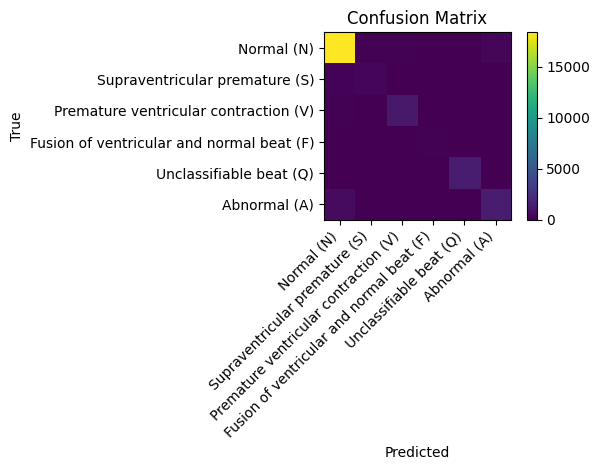

,precision,recall,f1-score,support
Normal (N),0.950028,0.971032,0.960415,18952.00000
Supraventricular premature (S),0.698189,0.624101,0.659069,556.00000
Premature ventricular contraction (V),0.907791,0.877072,0.892167,1448.00000
Fusion of ventricular and normal beat (F),0.673575,0.802469,0.732394,162.00000
Unclassifiable beat (Q),0.990759,0.933458,0.961255,1608.00000
Abnormal (A),0.812363,0.714974,0.760563,2077.00000
accuracy,0.932790,0.932790,0.932790,0.93279
macro avg,0.838784,0.820517,0.827644,24803.00000
weighted avg,0.931224,0.932790,0.931505,24803.00000


In [7]:

# ----------------------------------------------------
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# ---------- 1. Loss ---------------------------------
plt.figure()
plt.plot(epochs, history_dict['loss'], label='train')
plt.plot(epochs, history_dict['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss per Epoch')
plt.legend(); plt.show()

# ---------- 2. Accuracy -----------------------------
plt.figure()
plt.plot(epochs, history_dict['accuracy'], label='train')
plt.plot(epochs, history_dict['val_accuracy'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy per Epoch')
plt.legend(); plt.show()

# ---------- 3. PR-AUC -------------------------------
plt.figure()
plt.plot(epochs, history_dict['pr_auc'], label='train')
plt.plot(epochs, history_dict['val_pr_auc'], label='val')
plt.xlabel('Epoch'); plt.ylabel('PR AUC'); plt.title('PR-AUC per Epoch')
plt.legend(); plt.show()

# ---------- 4. Confusion Matrix ---------------------
y_true = np.argmax(y_test_cat, axis=1)
probs   = model.predict(X_test, batch_size=256, verbose=0)
y_pred  = np.argmax(probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix'); plt.colorbar()
tick_marks = np.arange(len(conditions))
plt.xticks(tick_marks, [conditions[i] for i in tick_marks], rotation=45, ha='right')
plt.yticks(tick_marks, [conditions[i] for i in tick_marks])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

# ---------- 5. Classification Report ---------------
report = classification_report(
    y_true, y_pred,
    target_names=[conditions[i] for i in range(len(conditions))],
    output_dict=True
)
pd.DataFrame(report).T


97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


C:\Users\plui0\AppData\Local\Temp\ipykernel_29812\2517984780.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", num_classes)


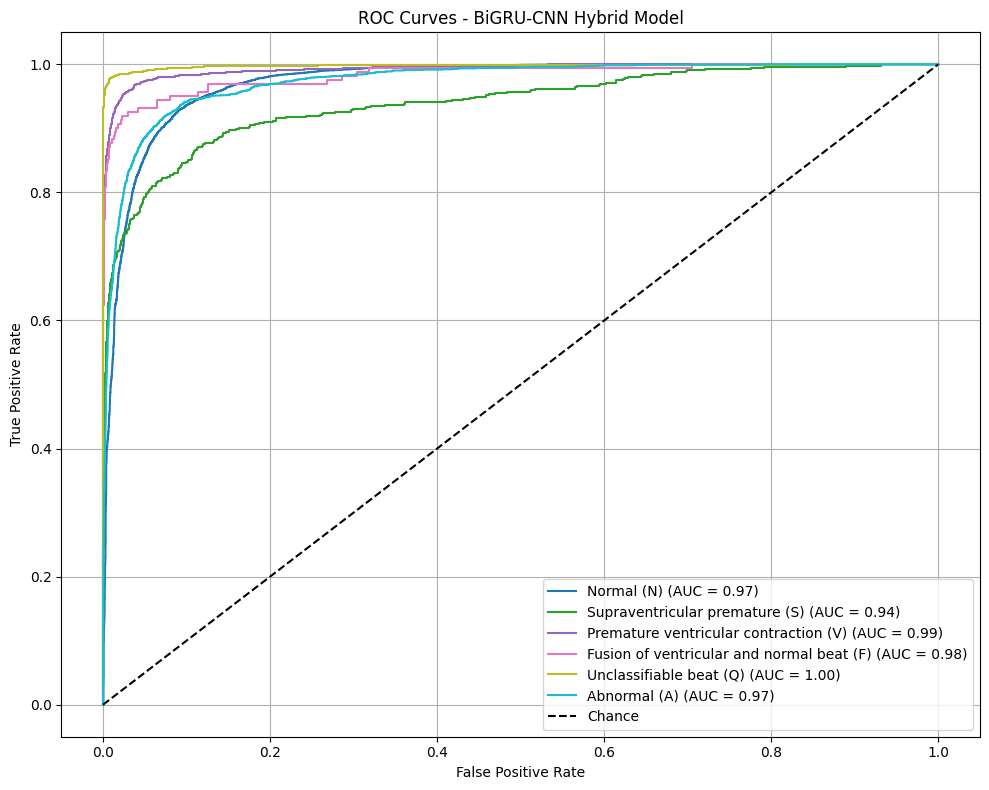

In [9]:
# ==================== ROC & AUC Curve (per-class) ====================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Predict probabilities
y_score = tf.nn.softmax(model.predict(X_test, batch_size=256), axis=-1).numpy()
y_true  = np.argmax(y_test_cat, axis=1)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap("tab10", num_classes)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{conditions[i]} (AUC = {roc_auc[i]:.2f})", color=colors(i))

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - BiGRU-CNN Hybrid Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
